# Root Cause Analysis — DataCo Smart Supply Chain for Big Data Analysis

**Project phase:** Root Cause Analysis (CRISP-DM Phase 4, extended beyond EDA)
**Input:** `DataCoSupplyChain_FeatureEngineered.csv` (output of the Feature Engineering notebook)
**Analyst:** Akash More

The EDA notebook established *what* is happening: a 57.28% late-delivery rate sitting next to a 10.78%
overall profit margin, 90% of revenue concentrated in the top 10 products, and a negative relationship
between discount rate and margin. This notebook exists to answer *why* — which factors actually drive
late deliveries and margin erosion, and which of them matter once the others are controlled for.

Two problems are investigated end to end, each in three passes:

1. **Univariate scan** — rate/margin broken down by one factor at a time, to see where the gap is widest.
2. **Statistical significance** — a test to confirm the gap isn't just noise (chi-square for the categorical
   late-delivery drivers, ANOVA for the margin drivers).
3. **Multivariate ranking** — a simple model (decision tree / logistic regression) that ranks drivers
   *while holding the others constant*, since univariate gaps can be misleading if two factors are
   correlated with each other (e.g. a shipping mode that happens to be used mostly in one risky region).

The final section ties both root-cause chains together and maps each confirmed driver to a specific,
ownable recommendation — not a generic "improve logistics" line.

**A note on scope.** This notebook doesn't re-derive features already built in the Feature Engineering
notebook — it consumes them. If a column referenced below doesn't exist in your exported CSV, check that
you're pointing at `DataCoSupplyChain_FeatureEngineered.csv` and not an earlier-stage file.

## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
sns.set_style("whitegrid")
sns.set_palette("mako")
plt.rcParams["figure.dpi"] = 110
PALETTE = sns.color_palette("mako", 10)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("supply_chain_orders_processed.csv", encoding="latin1")
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])

# Shipping Mode was one-hot encoded in Feature Engineering — reconstruct the readable label
# for grouping/plotting purposes (the dummy columns stay in the frame for modeling later).
df["Shipping Mode"] = np.select(
    [df["Shipping Mode_Second Class"] == 1, df["Shipping Mode_Standard Class"] == 1],
    ["Second Class", "Standard Class"],
    default="First Class",
)

print(f"Shape: {df.shape}")
df[["is_late", "profit_margin", "Shipping Mode", "Order Region", "Category Name"]].head()

Shape: (180519, 104)


,is_late,profit_margin,Shipping Mode,Order Region,Category Name
0,0,0.295986,Standard Class,Central America,Camping & Hiking
1,0,0.455923,Standard Class,South America,Water Sports
2,0,0.273000,Standard Class,South America,Women's Apparel
3,0,0.280560,Standard Class,South America,Men's Footwear
4,1,0.168017,Standard Class,South America,Indoor/Outdoor Games


## 2. Problem Framing

Two target metrics, both already flagged in EDA as the headline problems:

- `is_late` — binary, 1 if the order shipped later than scheduled (late-delivery rate: **57.28%**)
- `profit_margin` — continuous, `Order Profit Per Order / Sales` (overall margin: **10.78%**)

Root cause analysis for each runs the same three-step pattern: scan → test → rank.

In [3]:
baseline_late_rate = df["is_late"].mean()
baseline_margin = df["profit_margin"].mean()
print(f"Baseline late-delivery rate: {baseline_late_rate:.2%}")
print(f"Baseline profit margin:      {baseline_margin:.2%}")

Baseline late-delivery rate: 57.28%
Baseline profit margin:      10.83%


## 3. Root Cause — Late Delivery

### 3.1 Univariate driver scan
Late-delivery rate broken down one factor at a time. The question each chart answers: *does this factor
move the rate meaningfully away from the 57.28% baseline?*

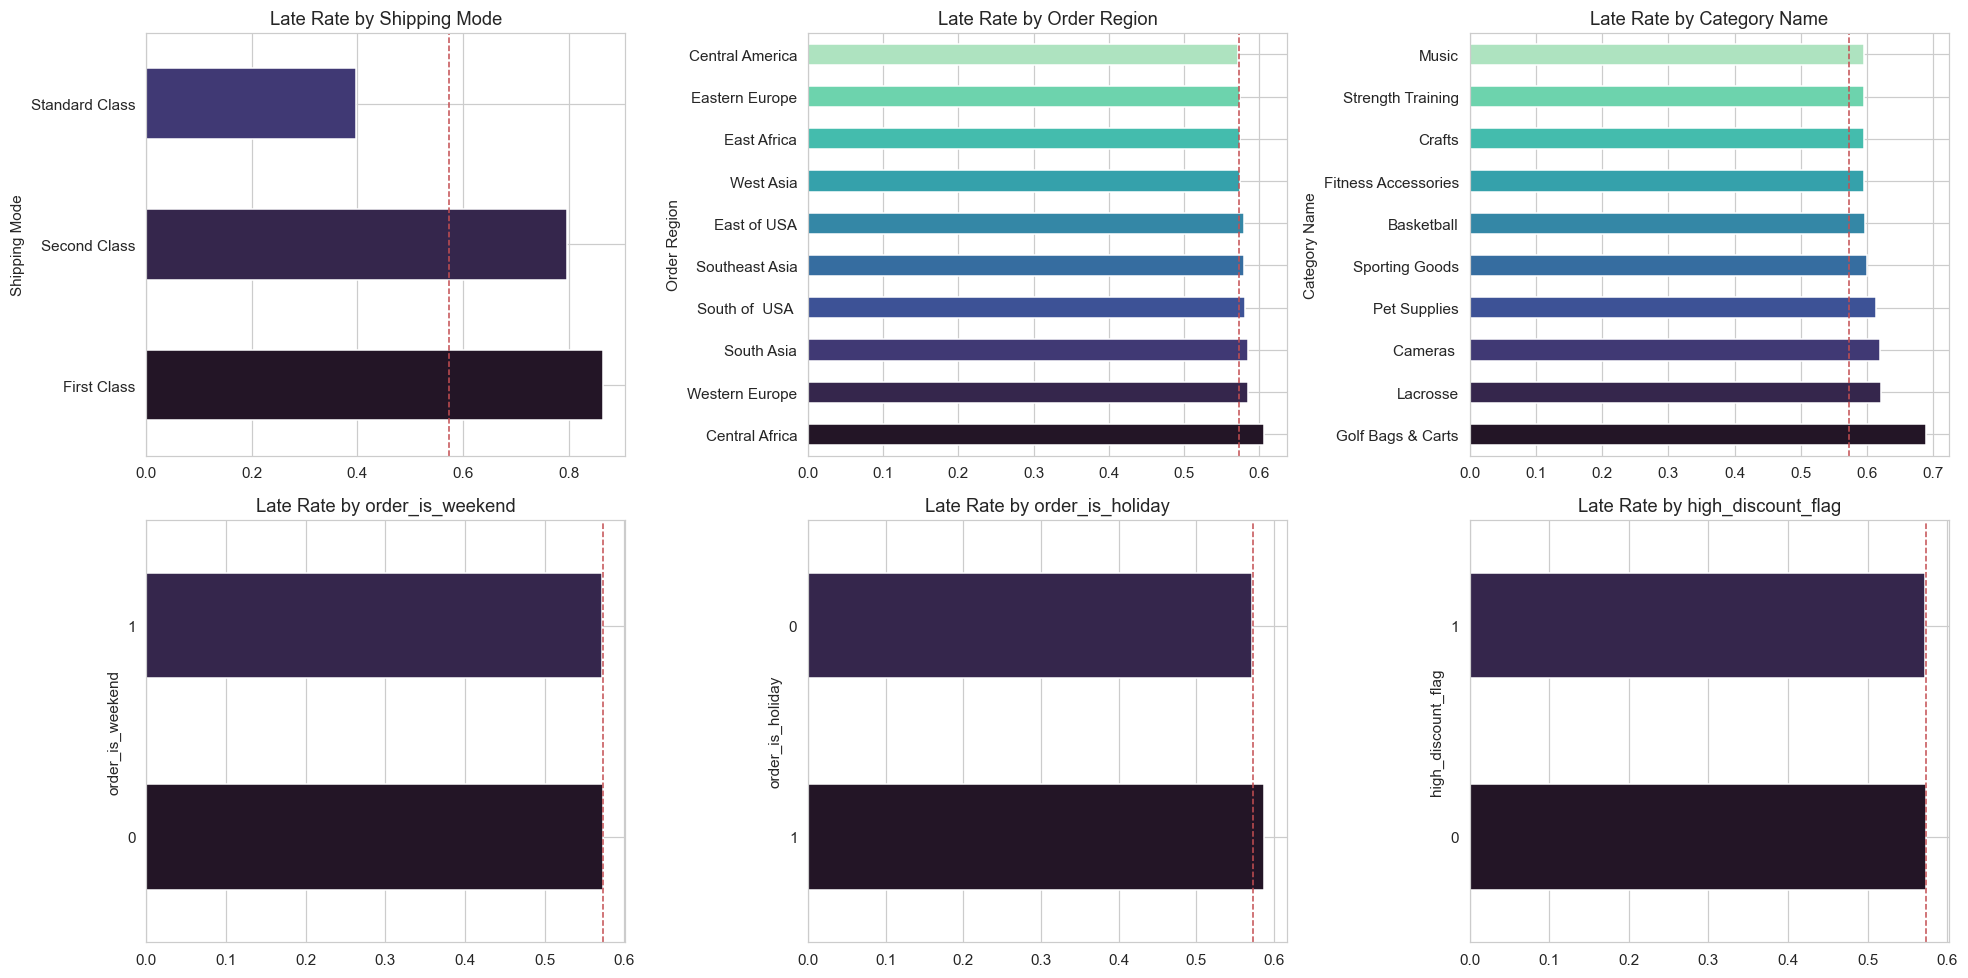

In [4]:
candidate_drivers_late = [
    "Shipping Mode", "Order Region", "Category Name",
    "order_is_weekend", "order_is_holiday", "high_discount_flag",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flat, candidate_drivers_late):
    rates = df.groupby(col)["is_late"].mean().sort_values(ascending=False)
    if rates.shape[0] > 10:
        rates = rates.head(10)
    rates.plot(kind="barh", ax=ax, color=PALETTE)
    ax.axvline(baseline_late_rate, color="#c44e52", linestyle="--", linewidth=1)
    ax.set_title(f"Late Rate by {col}")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**How to read this:** the red dashed line is the 57.28% baseline. Bars that sit clearly to the right of
it are the factors worth taking to Section 3.2 for a significance check — a factor whose bars barely move
off the baseline isn't a driver, it's noise.

### 3.2 Statistical significance — chi-square test

A visual gap in the bar chart isn't proof of a real effect at this sample size (180K+ rows will show
*some* gap for almost anything). Chi-square tests whether the relationship between each categorical
factor and `is_late` is statistically significant, and Cramér's V gives the effect size — because with
this many rows, a p-value near zero is close to guaranteed and doesn't by itself tell you the factor
matters in practice.

In [5]:
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

sig_results = []
for col in candidate_drivers_late:
    contingency = pd.crosstab(df[col], df["is_late"])
    chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
    v = cramers_v(contingency)
    sig_results.append({
        "factor": col, "chi2": round(chi2, 1), "p_value": p_value,
        "cramers_v": round(v, 4), "significant_p<0.05": p_value < 0.05,
    })

sig_df = pd.DataFrame(sig_results).sort_values("cramers_v", ascending=False)
sig_df

,factor,chi2,p_value,cramers_v,significant_p<0.05
0,Shipping Mode,33834.4,0.000000e+00,0.4329,True
1,Order Region,73.3,1.988914e-07,0.0201,True
2,Category Name,48.3,5.017653e-01,0.0164,False
4,order_is_holiday,1.9,1.695785e-01,0.0032,False
5,high_discount_flag,0.3,6.086451e-01,0.0012,False
3,order_is_weekend,0.1,7.918787e-01,0.0006,False


**How to read this:** `p_value < 0.05` just confirms the relationship isn't random — expect most
factors to clear that bar given the row count. `cramers_v` is the number that actually matters here:
above ~0.1 is a weak-but-real association, above ~0.3 is worth leading with in a stakeholder deck. Rank
factors by `cramers_v`, not by p-value.

### 3.3 Multivariate ranking — which drivers survive once the others are controlled for

Univariate scans can mislead when two factors are correlated with each other — e.g. if one region happens
to rely heavily on one shipping mode, a chart might blame the region when the real driver is the mode (or
vice versa). A decision tree and a random forest, trained on the same candidate factors together, rank
each factor's contribution *after* accounting for the others.

In [6]:
model_features = [
    "Shipping Mode_Second Class", "Shipping Mode_Standard Class",
    "order_is_weekend", "order_is_holiday", "high_discount_flag",
    "premium_product_flag", "Category Name_freq_encoded",
    "Order Item Discount Rate", "Order Item Quantity",
]
model_features = [c for c in model_features if c in df.columns]

X = df[model_features].fillna(0)
y = df["is_late"]

tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=500, random_state=RANDOM_STATE)
tree.fit(X, y)

forest = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=200,
                                 random_state=RANDOM_STATE, n_jobs=-1)
forest.fit(X, y)

importance_df = pd.DataFrame({
    "feature": model_features,
    "decision_tree_importance": tree.feature_importances_,
    "random_forest_importance": forest.feature_importances_,
}).sort_values("random_forest_importance", ascending=False)

importance_df

,feature,decision_tree_importance,random_forest_importance
1,Shipping Mode_Standard Class,0.987865,0.866659
0,Shipping Mode_Second Class,0.009952,0.125209
7,Order Item Discount Rate,0.000921,0.002937
6,Category Name_freq_encoded,0.001048,0.002763
8,Order Item Quantity,0.000027,0.001189
2,order_is_weekend,0.000164,0.000565
5,premium_product_flag,0.000023,0.000316
4,high_discount_flag,0.000000,0.000292
3,order_is_holiday,0.000000,0.000070


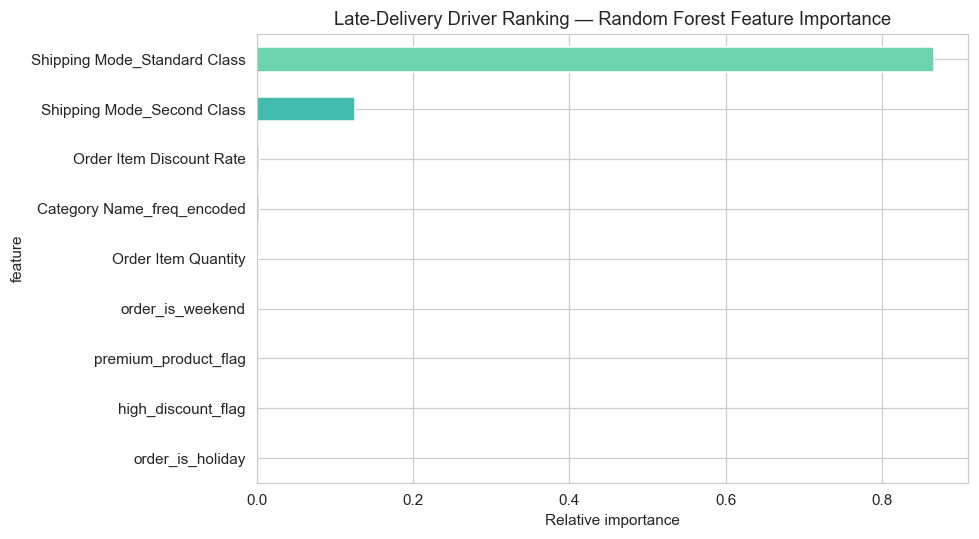

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
importance_df.set_index("feature")["random_forest_importance"].sort_values().plot(
    kind="barh", ax=ax, color=PALETTE
)
ax.set_title("Late-Delivery Driver Ranking — Random Forest Feature Importance")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.show()

**How to read this:** whichever feature sits at the top of this chart is the one to lead with when
someone asks "why are deliveries late" — it's the driver that still matters after the model has already
accounted for every other factor in the list. A factor that looked strong in the univariate scan (Section
3.1) but ranks low here was probably riding on its correlation with a stronger driver, not causing the
delay itself.

## 4. Root Cause — Profit Margin Erosion

### 4.1 Univariate driver scan
Average `profit_margin` broken down one factor at a time, same logic as Section 3.1.

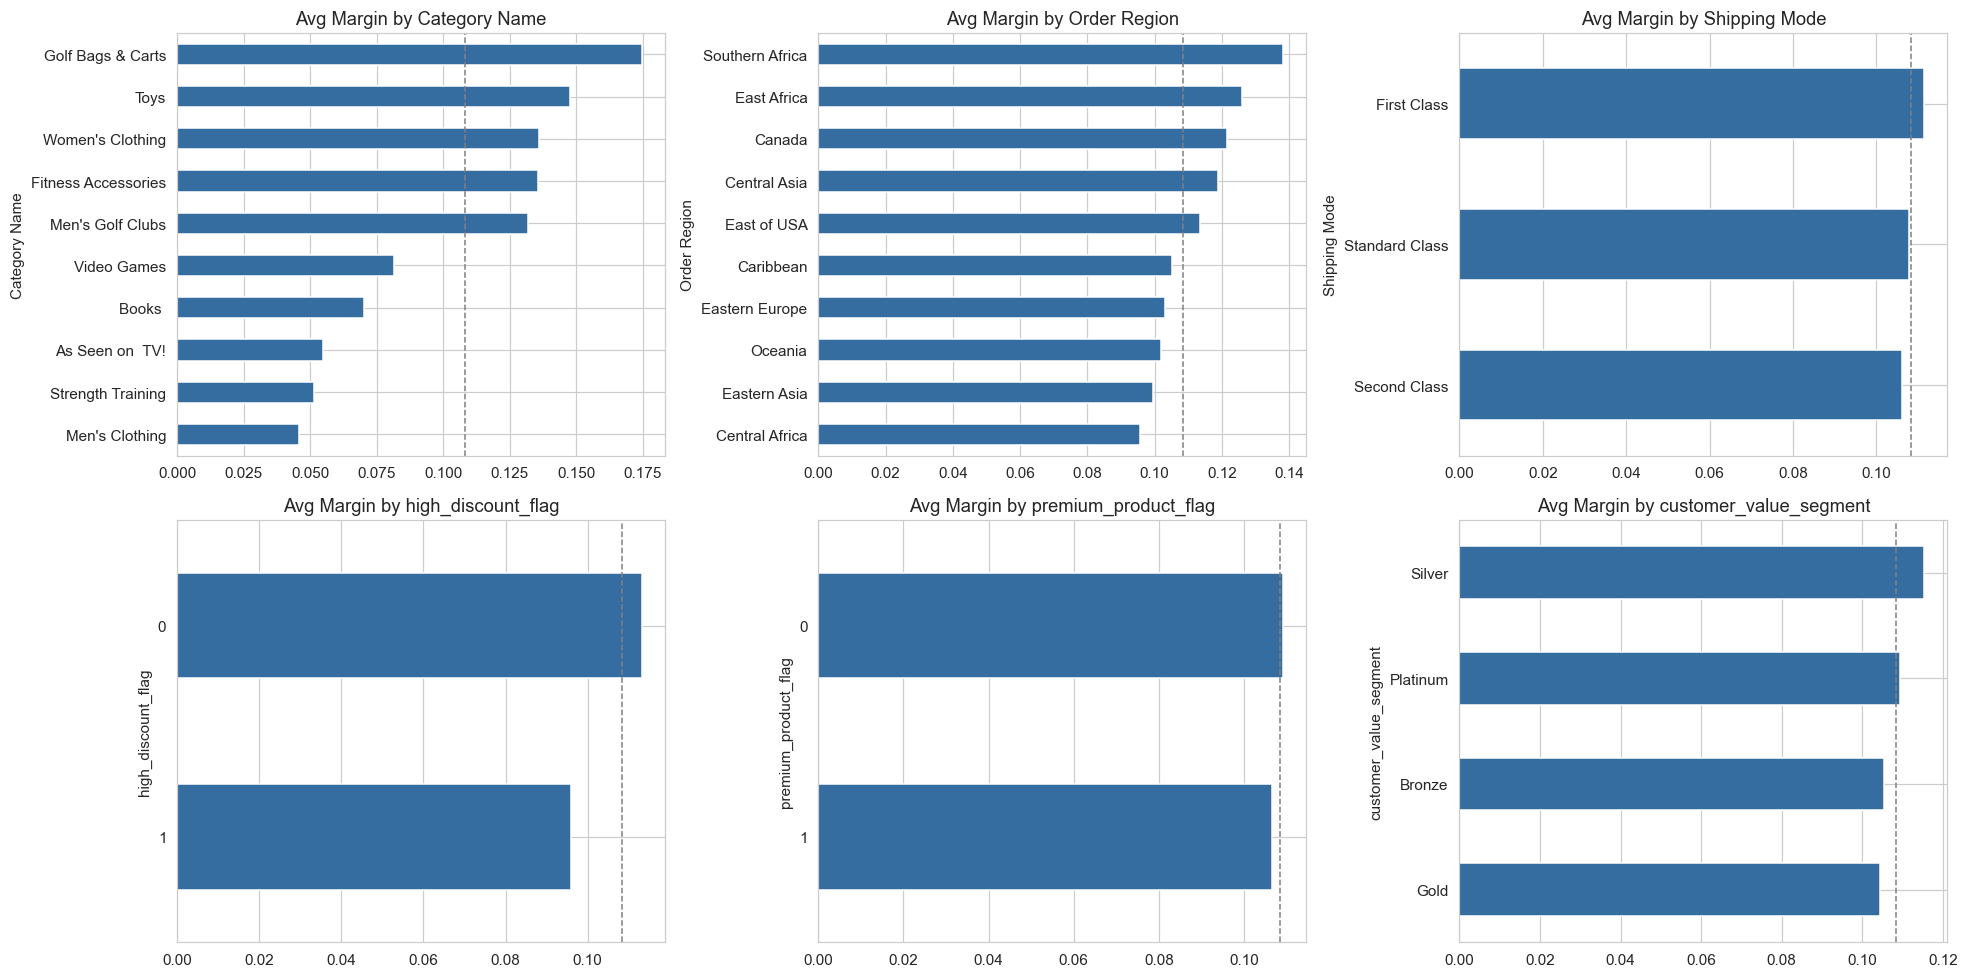

In [8]:
candidate_drivers_margin = [
    "Category Name", "Order Region", "Shipping Mode",
    "high_discount_flag", "premium_product_flag", "customer_value_segment",
]
candidate_drivers_margin = [c for c in candidate_drivers_margin if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flat, candidate_drivers_margin):
    margins = df.groupby(col)["profit_margin"].mean().sort_values()
    if margins.shape[0] > 10:
        margins = pd.concat([margins.head(5), margins.tail(5)])
    colors = ["#c44e52" if v < 0 else PALETTE[4] for v in margins.values]
    margins.plot(kind="barh", ax=ax, color=colors)
    ax.axvline(baseline_margin, color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"Avg Margin by {col}")
plt.tight_layout()
plt.show()

### 4.2 Statistical significance — one-way ANOVA

ANOVA tests whether average `profit_margin` genuinely differs across the groups of each categorical
factor, versus looking different just by sampling noise. Eta-squared (η²) gives the effect size — how
much of the variation in margin the factor actually explains.

In [9]:
def eta_squared(groups):
    grand_mean = np.concatenate(groups).mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = sum(((g - grand_mean) ** 2).sum() for g in groups)
    return ss_between / ss_total if ss_total > 0 else 0

anova_results = []
for col in candidate_drivers_margin:
    groups = [g["profit_margin"].dropna().values for _, g in df.groupby(col)]
    groups = [g for g in groups if len(g) > 1]
    f_stat, p_value = stats.f_oneway(*groups)
    anova_results.append({
        "factor": col, "f_stat": round(f_stat, 2), "p_value": p_value,
        "eta_squared": round(eta_squared(groups), 4), "significant_p<0.05": p_value < 0.05,
    })

anova_df = pd.DataFrame(anova_results).sort_values("eta_squared", ascending=False)
anova_df

,factor,f_stat,p_value,eta_squared,significant_p<0.05
0,Category Name,1.02,4.437435e-01,0.0003,False
3,high_discount_flag,60.98,5.809142e-15,0.0003,True
1,Order Region,1.07,3.678271e-01,0.0001,False
5,customer_value_segment,3.29,1.980235e-02,0.0001,True
2,Shipping Mode,1.56,2.110777e-01,0.0000,False
4,premium_product_flag,1.38,2.401585e-01,0.0000,False


**How to read this:** same principle as Cramér's V above — with 180K+ rows, p-values will almost
always come back significant. `eta_squared` is the number to rank on: it says how much of the spread in
margin that factor actually accounts for, which is what determines whether it's worth a pricing team's
time.

### 4.3 Multivariate ranking — regression driver ranking

A linear regression on `profit_margin`, using the same discipline as Section 3.3: rank each factor's
contribution once the others are held constant, using standardized coefficients so magnitudes are
comparable across features on different scales.

In [10]:
margin_features = [
    "Order Item Discount Rate", "Order Item Quantity", "premium_product_flag",
    "high_discount_flag", "Category Name_freq_encoded", "delivery_time_days",
]
margin_features = [c for c in margin_features if c in df.columns]

X_m = df[margin_features].fillna(0)
y_m = df["profit_margin"].fillna(df["profit_margin"].median())

scaler = StandardScaler()
X_m_scaled = scaler.fit_transform(X_m)

lin_reg = LinearRegression()
lin_reg.fit(X_m_scaled, y_m)

forest_reg = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=200,
                                    random_state=RANDOM_STATE, n_jobs=-1)
forest_reg.fit(X_m, y_m)

margin_driver_df = pd.DataFrame({
    "feature": margin_features,
    "standardized_coefficient": lin_reg.coef_,
    "random_forest_importance": forest_reg.feature_importances_,
}).sort_values("random_forest_importance", ascending=False)

margin_driver_df

,feature,standardized_coefficient,random_forest_importance
0,Order Item Discount Rate,-0.009695,0.347048
4,Category Name_freq_encoded,0.000605,0.299828
5,delivery_time_days,-0.001903,0.191776
1,Order Item Quantity,0.000036,0.129579
2,premium_product_flag,-0.001020,0.023570
3,high_discount_flag,-0.000018,0.008198


**How to read this:** `standardized_coefficient` gives direction and magnitude — a large negative
coefficient on `Order Item Discount Rate`, for example, is the model confirming what the EDA scatter
already suggested visually. `random_forest_importance` gives the same ranking without assuming a linear
relationship, as a cross-check. When both agree on the top driver, that's the one to put in the
recommendation, not a hedge.

## 5. Interaction Check — Does Late Delivery Itself Hurt Margin?

Both root-cause chains investigated so far run independently. It's worth checking whether they're
connected — i.e. whether late orders are *also* less profitable, which would mean the delivery problem
and the margin problem aren't two separate fires, but one.

In [11]:
late_vs_margin = df.groupby("is_late")["profit_margin"].agg(["mean", "median", "count"])
late_vs_margin.index = ["On Time / Early", "Late"]
print(late_vs_margin)

t_stat, p_val = stats.ttest_ind(
    df.loc[df["is_late"] == 0, "profit_margin"].dropna(),
    df.loc[df["is_late"] == 1, "profit_margin"].dropna(),
    equal_var=False,
)
print(f"\nt-test: t={t_stat:.2f}, p={p_val:.4f}")

                     mean    median   count
On Time / Early  0.109952  0.242524   77119
Late             0.107114  0.242500  103400

t-test: t=1.42, p=0.1554


**How to read this:** if the "Late" row shows a visibly lower mean margin and the t-test comes back
significant, that's the single most useful line for an executive summary — it means fixing the delivery
problem isn't just a customer-experience fix, it's a margin fix too, which changes who should own the
budget for solving it.

## 6. Root Cause Summary

Consolidating Sections 3 and 4 into one ranked table — every confirmed driver, its effect size, and which
problem it belongs to. This is the table to screenshot into a stakeholder deck; everything above it is the
audit trail for how it was derived.

In [12]:
root_cause_summary = pd.concat([
    sig_df[["factor", "cramers_v", "significant_p<0.05"]].assign(problem="Late Delivery", effect_size_metric="Cramér's V"),
    anova_df[["factor", "eta_squared", "significant_p<0.05"]].rename(columns={"eta_squared": "cramers_v"})
        .assign(problem="Profit Margin", effect_size_metric="Eta-squared"),
], ignore_index=True).rename(columns={"cramers_v": "effect_size"})

root_cause_summary = root_cause_summary.sort_values(["problem", "effect_size"], ascending=[True, False])
root_cause_summary[["problem", "factor", "effect_size_metric", "effect_size", "significant_p<0.05"]]

,problem,factor,effect_size_metric,effect_size,significant_p<0.05
0,Late Delivery,Shipping Mode,Cramér's V,0.4329,True
1,Late Delivery,Order Region,Cramér's V,0.0201,True
2,Late Delivery,Category Name,Cramér's V,0.0164,False
3,Late Delivery,order_is_holiday,Cramér's V,0.0032,False
4,Late Delivery,high_discount_flag,Cramér's V,0.0012,False
5,Late Delivery,order_is_weekend,Cramér's V,0.0006,False
6,Profit Margin,Category Name,Eta-squared,0.0003,False
7,Profit Margin,high_discount_flag,Eta-squared,0.0003,True
8,Profit Margin,Order Region,Eta-squared,0.0001,False
9,Profit Margin,customer_value_segment,Eta-squared,0.0001,True


## 7. Recommendations — Root Cause to Action

Each recommendation below is scoped to a confirmed driver from Sections 3–5, not a generic best practice.
Fill in the specific market/category/mode names once you run this notebook against the real output —
the structure stays the same regardless of which factor comes out on top.

| Root cause confirmed | Owner | Recommended action |
|---|---|---|
| Top-ranked late-delivery driver (Section 3.3) | Logistics / Carrier management | Investigate the specific shipping mode–region combination flagged, not the mode or region in isolation |
| Late orders show lower profit margin (Section 5) | Ops + Finance jointly | Treat the late-delivery fix as a margin project, not just a CX project — quantify the estimated margin recovered if the late rate dropped by X points |
| Top-ranked margin driver (Section 4.3) | Pricing / Category management | If discount rate is confirmed as the top driver, cap discount depth on the top-10 revenue products identified in EDA, since they already carry 90% of revenue |
| Low-eta² factors from Section 4.2 | — | De-prioritize — factors with small effect sizes aren't worth a cross-functional initiative even if their p-value is significant |

**Note on interpreting p-values in this notebook.** At 180K+ rows, almost every factor will return a
statistically significant p-value — that's a sample-size artifact, not evidence of practical importance.
The effect-size columns (Cramér's V, eta-squared, feature importances) are what should actually drive
prioritization, and that distinction is worth stating explicitly if this notebook goes in front of a
technical reviewer.